In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [11]:
file_path = r"cleaned_dataset_without_criticalcolumns.csv"
#file_path = r"cleaned_dataset.csv"
df = pd.read_csv(file_path)

In [12]:
features = [col for col in df.columns if col not in ['ID', 'Choice']]
X = df[features]
y = df['Choice']

X = X.fillna(X.median(numeric_only=True))

X = X.dropna(axis=1, how='all')
mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled_all = scaler.fit_transform(X)

print("\nMultinomial Logistic Regression")
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42)


Multinomial Logistic Regression


In [13]:
cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
print("\nCross-Validation")
print(f"five-folder Accuracy: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f} ")

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n Test Set Evaluation")
print(f"Accuracy: {acc:.4f}")
print(f" Macro F1: {macro_f1:.4f}")

print("\nClassification Report")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Cross-Validation
five-folder Accuracy: [0.82022472 0.68361582 0.66666667 0.71751412 0.68361582]
Mean Accuracy: 0.7143
Standard Deviation: 0.0555 

 Test Set Evaluation
Accuracy: 0.8146
 Macro F1: 0.6784

Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.66      0.73        56
         1.0       0.86      0.90      0.88       115
         2.0       0.33      0.57      0.42         7

    accuracy                           0.81       178
   macro avg       0.67      0.71      0.68       178
weighted avg       0.83      0.81      0.82       178



c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


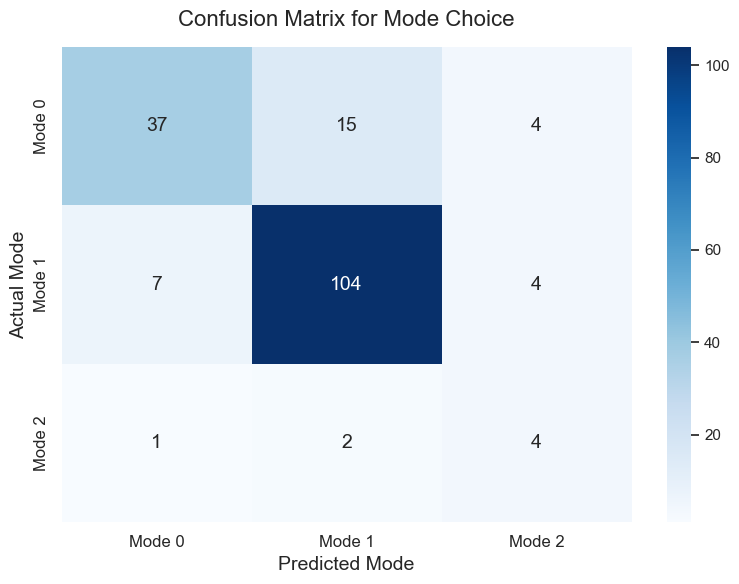

In [14]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Mode 0', 'Mode 1', 'Mode 2'], 
                 yticklabels=['Mode 0', 'Mode 1', 'Mode 2'],
                 annot_kws={"size": 14}) 

plt.title('Confusion Matrix for Mode Choice', fontsize=16, pad=15)
plt.xlabel('Predicted Mode', fontsize=14)
plt.ylabel('Actual Mode', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()